In [67]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import statistics
from scipy.stats import lognorm
from scipy.stats import norm
from scipy.stats import uniform

In [54]:
# sim
p = "D:/Projects/GNN Research/Data Files/_sim_tr_csv_data_gnn/2025-08-20_old/"
l = [f+"/"+os.listdir(f)[0]+"/"+"Trackrefiner.Objects properties_Average_analysis.csv" for f in [p+f for f in [f for f in os.listdir(p)]][:100]]
list_sim = []
for f in l:
    d = pd.read_csv(f)
    list_sim.append(max(d["ObjectNumber"].dropna().tolist()))
max_sim = max(list_sim)
min_sim = min(list_sim)
mean_sim = statistics.mean(list_sim)
var_sim = statistics.variance(list_sim)

In [55]:
# exp
ep = "D:/Projects/GNN Research/Data Files/_exp_data/node/"
el = [ep+ef for ef in os.listdir(ep)]
list_exp = []
for ef in el:
    ed = pd.read_csv(ef)
    list_exp.append(max(ed["ObjectNumber"].dropna().tolist()))
max_exp = max(list_exp)
min_exp = min(list_exp)
mean_exp = statistics.mean(list_exp)
var_exp = statistics.variance(list_exp)

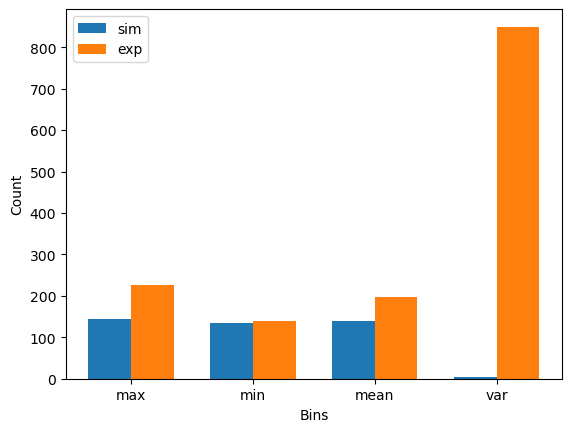

In [57]:
bin_names = ["max", "min", "mean", "var"]
list1 = [max_sim, min_sim, mean_sim, var_sim]
list2 = [max_exp, min_exp, mean_exp, var_exp]

x = np.arange(len(bin_names))
width = 0.35

plt.bar(x - width/2, list1, width, label="sim")
plt.bar(x + width/2, list2, width, label="exp")

plt.xticks(x, bin_names)
plt.xlabel("Bins")
plt.ylabel("Count")
plt.legend()

plt.show()

In [62]:
def get_plot_exp(data):
    data = np.array(data)
    mean_val = data.mean()

    kde = gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 1000)

    plt.hist(data, bins=24, density=True)
    plt.plot(x, kde(x))
    plt.axvline(mean_val, color='yellow', linestyle='--', linewidth=2, label=f"Mean = {mean_val:.2f}")

    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.title("Histogram + KDE with Mean")
    plt.legend()
    plt.show()

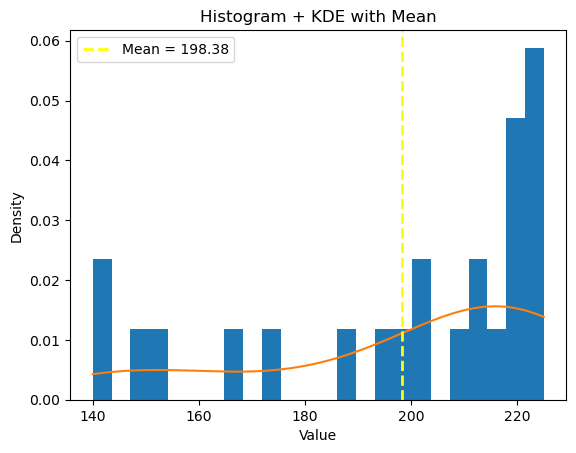

In [63]:
get_plot_exp(list_exp)

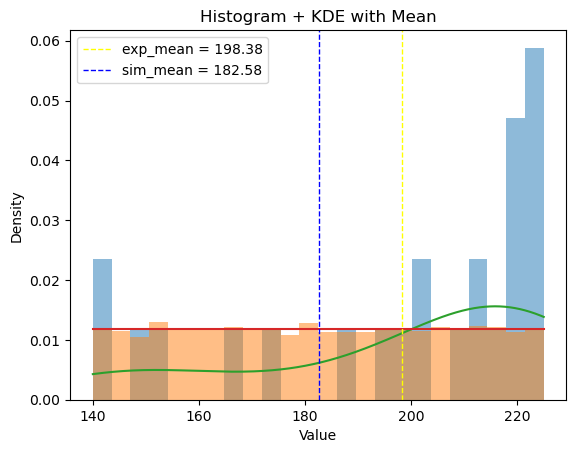

In [71]:
min_val = min(list_exp)
max_val = max(list_exp)
samples = uniform.rvs(loc=min_val, scale=max_val - min_val, size=10000)

data = np.array(list_exp)
    
mean_exp = data.mean()
mean_sim = samples.mean()

x_exp = np.linspace(data.min(), data.max(), 1000)
x_sim = np.linspace(min(samples), max(samples), 1000)
    
kde = gaussian_kde(data)
pdf = uniform.pdf(x_sim, loc=min_val, scale=max_val - min_val)

plt.hist(data, bins=24, density=True, alpha=0.5)
plt.hist(samples, bins=24, density=True, alpha=0.5)
    
plt.plot(x_exp, kde(x_exp))
plt.plot(x_sim, pdf)
    
plt.axvline(mean_exp, color='yellow', linestyle='--', linewidth=1, label=f"exp_mean = {mean_exp:.2f}")
plt.axvline(mean_sim, color='blue', linestyle='--', linewidth=1, label=f"sim_mean = {mean_sim:.2f}")

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Histogram + KDE with Mean")
plt.legend()
plt.show()

In [72]:
max_exp, min_exp

(225, 140)